# Delay Prediction in Dutch Train Services
## Model: LSTM — Prédiction en cours de trajet

### Objectif

Ce notebook utilise un **LSTM (Long Short-Term Memory)** pour prédire si un service va terminer avec un retard sévère (> 5 min), en exploitant la **séquence ordonnée des stops** du trajet.

**Différence fondamentale avec XGBoost :**

| Modèle | Vision des données | Type de prédiction |
|---|---|---|
| Logistic Regression | Service agrégé (1 ligne) | Avant départ |
| XGBoost | Service agrégé (1 ligne) | Avant départ |
| **LSTM** | **Séquence de stops (N lignes)** | **En cours de trajet** |

**Cas d'usage réel :** un système d'information voyageurs qui, après chaque stop, met à jour la probabilité que le train arrive en retard significatif à destination.

**Cadre :** le LSTM utilise les retards observés aux stops intermédiaires — ces données ne sont disponibles qu'en temps réel pendant le trajet, pas avant le départ. C'est un modèle de **prédiction dynamique**, complémentaire à XGBoost.

```

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.labelsize': 11})
PALETTE = sns.color_palette('muted')

print(f'TensorFlow version : {tf.__version__}')
print(f'Keras version      : {keras.__version__}')

TensorFlow version : 2.20.0
Keras version      : 3.10.0


### 2. Loading and Preparing the Dataset

In [2]:
df_clean = pd.read_csv('df_clean.csv', low_memory=False)
print(f'df_clean loaded: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns')

# ── Datetime conversions ──────────────────────────────────────────────────────
df_clean['Service:Date']        = pd.to_datetime(df_clean['Service:Date'], errors='coerce')
df_clean['Stop:Departure time'] = pd.to_datetime(df_clean['Stop:Departure time'], utc=True, errors='coerce')
df_clean['Stop:Arrival time']   = pd.to_datetime(df_clean['Stop:Arrival time'],   utc=True, errors='coerce')

df_clean['dep_hour'] = (
    df_clean['Stop:Departure time']
    .dt.tz_convert('Europe/Amsterdam')
    .dt.hour
)

# ── Boolean → int ─────────────────────────────────────────────────────────────
bool_cols = ['Stop:Platform change', 'Service:Completely cancelled',
             'Service:Partly cancelled', 'Stop:Arrival cancelled',
             'Stop:Departure cancelled']
for col in bool_cols:
    if col in df_clean.columns:
        df_clean[col] = (
            df_clean[col].astype(str).str.strip().str.lower()
            .map({'true': 1, 'false': 0, '1': 1, '0': 0})
            .fillna(0).astype(int)
        )

df_clean['Stop:Arrival delay']   = pd.to_numeric(df_clean['Stop:Arrival delay'],   errors='coerce').fillna(0)
df_clean['Stop:Departure delay'] = pd.to_numeric(df_clean['Stop:Departure delay'], errors='coerce').fillna(0)
df_clean['Service:Maximum delay']= pd.to_numeric(df_clean['Service:Maximum delay'],errors='coerce')

# ── Stop index au sein du service ─────────────────────────────────────────────
df_clean['stop_index'] = df_clean.groupby('Service:RDT-ID').cumcount()

print('Preprocessing done.')
df_clean.head(3)

df_clean loaded: 21,838,516 rows, 17 columns
Preprocessing done.


,Service:RDT-ID,Service:Date,Service:Type,Service:Company,Service:Train number,Service:Completely cancelled,Service:Partly cancelled,Service:Maximum delay,Stop:RDT-ID,Stop:Station name,Stop:Arrival time,Stop:Arrival delay,Stop:Arrival cancelled,Stop:Departure time,Stop:Departure delay,Stop:Departure cancelled,Stop:Platform change,dep_hour,stop_index
0,12690865,2024-01-01,Intercity,NS,1410,0,0,2,114307592,Rotterdam Centraal,NaT,0.0,1,2024-01-01 01:00:00+00:00,0.0,0,0,2.0,0
1,12690865,2024-01-01,Intercity,NS,1410,0,0,0,114307593,Delft,2024-01-01 01:13:00+00:00,0.0,0,2024-01-01 01:13:00+00:00,0.0,0,0,2.0,1
2,12690865,2024-01-01,Intercity,NS,1410,0,0,0,114307594,Den Haag HS,2024-01-01 01:21:00+00:00,0.0,0,2024-01-01 01:22:00+00:00,0.0,0,0,2.0,2


### 3. Defining the Target and Sequence Features

**Target :** `severe_delay = 1` si le retard maximum du service > 5 min.

**Features par stop (séquence) :**

| Feature | Description | Disponibilité |
|---|---|---|
| `arr_delay` | Retard à l'arrivée au stop | Temps réel |
| `dep_delay` | Retard au départ du stop | Temps réel |
| `platform_change` | Changement de quai | Temps réel |
| `dep_hour` | Heure de départ du stop | Connu à l'avance |
| `stop_index` | Position du stop dans le trajet | Connu à l'avance |

In [3]:
# Target au niveau service
service_targets = (
    df_clean
    .groupby('Service:RDT-ID')['Service:Maximum delay']
    .first()
    .apply(lambda d: 1 if pd.notna(d) and d > 5 else 0)
    .reset_index()
    .rename(columns={'Service:Maximum delay': 'target'})
)

counts = service_targets['target'].value_counts()
pct    = service_targets['target'].value_counts(normalize=True) * 100
print('Target distribution:')
print(f'  0 – Retard ≤ 5 min : {counts[0]:>10,}  ({pct[0]:.1f}%)')
print(f'  1 – Retard > 5 min : {counts[1]:>10,}  ({pct[1]:.1f}%)')

Target distribution:
  0 – Retard ≤ 5 min :  2,193,409  (91.6%)
  1 – Retard > 5 min :    202,227  (8.4%)


### 4. Building Sequences

Chaque service devient une **matrice de shape (n_stops, n_features)**.

Comme les services n'ont pas tous le même nombre de stops, on applique un **padding** : on fixe une longueur maximale `MAX_LEN` et on complète les séquences courtes avec des zéros (pad à gauche).

On limite à `MAX_SERVICES` services pour éviter des temps de calcul trop longs.

In [23]:
MAX_LEN      = 20
MAX_SERVICES = 100_000

SEQ_FEATURES = [
    'Stop:Arrival delay',
    'Stop:Departure delay',
    'Stop:Platform change',
    'dep_hour',
    'stop_index'
]
N_FEATURES = len(SEQ_FEATURES)

# ── Nettoyage AVANT construction des séquences ────────────────────────────────
# Remplir les NaN restants dans les features séquentielles
df_clean['dep_hour']              = df_clean['dep_hour'].fillna(0)
df_clean['Stop:Arrival delay']    = df_clean['Stop:Arrival delay'].fillna(0)
df_clean['Stop:Departure delay']  = df_clean['Stop:Departure delay'].fillna(0)
df_clean['Stop:Platform change']  = df_clean['Stop:Platform change'].fillna(0)
df_clean['stop_index']            = df_clean['stop_index'].fillna(0)

# Vérification
for col in SEQ_FEATURES:
    n_nan = df_clean[col].isna().sum()
    print(f'NaN dans {col:<30} : {n_nan}')

# ── Sous-échantillon stratifié ────────────────────────────────────────────────
service_ids = service_targets['Service:RDT-ID'].values
targets_arr = service_targets['target'].values

idx_sample, _, y_sample, _ = train_test_split(
    np.arange(len(service_ids)), targets_arr,
    train_size=min(MAX_SERVICES, len(service_ids)),
    stratify=targets_arr,
    random_state=42
)
sampled_ids = service_ids[idx_sample]
sampled_y   = targets_arr[idx_sample]

print(f'\nServices sélectionnés : {len(sampled_ids):,}')

# ── Construction des séquences ────────────────────────────────────────────────
# Fraction du trajet visible par le modèle (ex: 0.5 = première moitié)
VISIBLE_FRACTION = 0.5

X_seq = np.zeros((len(sampled_ids), MAX_LEN, N_FEATURES), dtype=np.float32)

for i, sid in enumerate(sampled_ids):
    if sid not in grouped.groups:
        continue
    grp    = grouped.get_group(sid)[SEQ_FEATURES].values.astype(np.float32)
    grp    = np.nan_to_num(grp, nan=0.0)

    # On ne garde que les premiers stops (première moitié du trajet)
    n_visible = max(1, int(len(grp) * VISIBLE_FRACTION))
    grp       = grp[:n_visible]

    # Puis on tronque à MAX_LEN et on padde
    grp    = grp[:MAX_LEN]
    length = len(grp)
    X_seq[i, MAX_LEN - length:, :] = grp

# Vérification finale
print(f'\nX_seq — NaN : {np.isnan(X_seq).sum()}')
print(f'X_seq — min : {X_seq.min():.3f}, max : {X_seq.max():.3f}')
print(f'y_seq — % retards : {y_seq.mean()*100:.1f}%')

NaN dans Stop:Arrival delay             : 0
NaN dans Stop:Departure delay           : 0
NaN dans Stop:Platform change           : 0
NaN dans dep_hour                       : 0
NaN dans stop_index                     : 0

Services sélectionnés : 100,000

X_seq — NaN : 0
X_seq — min : 0.000, max : 250.000
y_seq — % retards : 8.4%


### 5. Normalisation des features

Les LSTM sont sensibles aux échelles. On normalise chaque feature indépendamment **sur le train set uniquement** pour éviter le leakage.

In [24]:
# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.20,
    random_state=42,
    stratify=y_seq
)

# Normalisation : mean et std calculés sur le train uniquement
# shape : (n_features,) — on normalise feature par feature
mean = X_train.mean(axis=(0, 1), keepdims=True)  # shape (1, 1, n_features)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

print(f'Train : {X_train.shape}  |  {y_train.mean()*100:.1f}% retards')
print(f'Test  : {X_test.shape}   |  {y_test.mean()*100:.1f}% retards')

Train : (80000, 20, 5)  |  8.4% retards
Test  : (20000, 20, 5)   |  8.4% retards


### 6. Class Weights

Le dataset est déséquilibré (~20% de retards). On utilise des **class weights** pour forcer le modèle à accorder plus d'importance aux retards sévères pendant l'entraînement.

In [25]:
classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = {0: weights[0], 1: weights[1]}

print(f'Class weight 0 (≤ 5 min) : {weights[0]:.3f}')
print(f'Class weight 1 (> 5 min) : {weights[1]:.3f}')

Class weight 0 (≤ 5 min) : 0.546
Class weight 1 (> 5 min) : 5.923


### 7. Building the LSTM Model

In [26]:
def build_lstm_model(max_len, n_features):
    model = keras.Sequential([
        # Ignore les timesteps de padding
        layers.Masking(mask_value=0.0, input_shape=(max_len, n_features)),

        # Couche LSTM principale
        layers.LSTM(64, return_sequences=False),

        # Régularisation
        layers.Dropout(0.3),

        # Couche de décision
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),

        # Output : probabilité binaire
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=0.001),
        loss      = 'binary_crossentropy',
        metrics   = [
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_lstm_model(MAX_LEN, N_FEATURES)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_2 (Masking)             │ (None, 20, 5)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Training

**Callbacks utilisés :**
- `EarlyStopping` → arrêt si la val_loss ne s'améliore plus pendant 5 epochs
- `ReduceLROnPlateau` → réduit le learning rate si la val_loss stagne

In [27]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    epochs          = 30,
    batch_size      = 512,
    validation_data = (X_test, y_test),
    class_weight    = class_weight_dict,
    callbacks       = callbacks,
    verbose         = 1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - auc: 0.8167 - loss: 0.5110 - precision: 0.2965 - recall: 0.6625 - val_auc: 0.8762 - val_loss: 0.3307 - val_precision: 0.4852 - val_recall: 0.6605 - learning_rate: 0.0010
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - auc: 0.8696 - loss: 0.4204 - precision: 0.4197 - recall: 0.6976 - val_auc: 0.8780 - val_loss: 0.3958 - val_precision: 0.4387 - val_recall: 0.6842 - learning_rate: 0.0010
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - auc: 0.8720 - loss: 0.4157 - precision: 0.4244 - recall: 0.6907 - val_auc: 0.8795 - val_loss: 0.3671 - val_precision: 0.4791 - val_recall: 0.6736 - learning_rate: 0.0010
Epoch 4/30
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - auc: 0.8722 - loss: 0.4041 - precision: 0.4605 - recall: 0.6892
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - auc: 0.8723 - loss: 0.4042 - precision: 0.4605 - recall: 0.6892 - val_auc: 0.8806 - va

### 9. Learning Curves

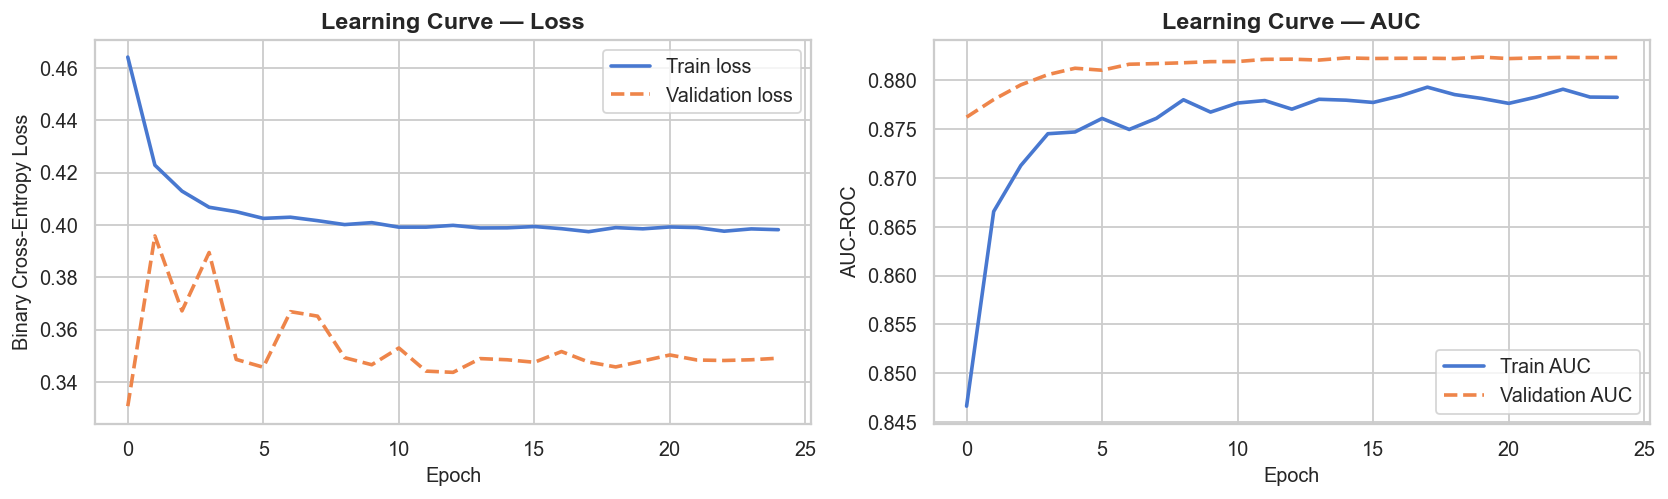

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(history.history['loss'],     label='Train loss',      color=PALETTE[0], linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation loss', color=PALETTE[1], linewidth=2, linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Learning Curve — Loss', fontweight='bold')
axes[0].legend()

# AUC
axes[1].plot(history.history['auc'],     label='Train AUC',      color=PALETTE[0], linewidth=2)
axes[1].plot(history.history['val_auc'], label='Validation AUC', color=PALETTE[1], linewidth=2, linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Learning Curve — AUC', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz_lstm_learning_curves.png', bbox_inches='tight')
plt.show()

In [29]:
# Diagnostic complet
print('=== DIAGNOSTIC ===')
print(f'X_test  — min: {X_test.min():.3f}, max: {X_test.max():.3f}, NaN: {np.isnan(X_test).sum()}')
print(f'y_train — min: {y_train.min():.3f}, max: {y_train.max():.3f}, NaN: {np.isnan(y_train).sum()}')

# Vérifier les poids du modèle
weights_ok = all(not np.any(np.isnan(w.numpy())) for w in model.weights)
print(f'Poids du modèle sans NaN : {weights_ok}')

# Test sur 5 exemples
test_sample = X_test[:5]
print(f'\nTest sur 5 exemples :')
print(f'Input sample — NaN : {np.isnan(test_sample).sum()}')
pred_sample = model(test_sample, training=False).numpy()
print(f'Output sample      : {pred_sample.flatten()}')

# Vérifier le loss final
final_loss = history.history['val_loss'][-1]
print(f'\nVal loss finale : {final_loss}')

=== DIAGNOSTIC ===
X_test  — min: -0.478, max: 86.721, NaN: 0
y_train — min: 0.000, max: 1.000, NaN: 0
Poids du modèle sans NaN : True

Test sur 5 exemples :
Input sample — NaN : 0
Output sample      : [0.20297736 0.48672235 0.15033633 0.6378086  0.4968986 ]

Val loss finale : 0.3490566313266754


### 10. Evaluation

In [30]:
y_pred_proba = model.predict(X_test, verbose=0).flatten()

# ── Vérification et nettoyage des NaN ────────────────────────────────────────
print(f'NaN dans y_pred_proba : {np.isnan(y_pred_proba).sum()}')
print(f'NaN dans y_test       : {np.isnan(y_test).sum()}')

# Masque pour garder uniquement les lignes sans NaN
mask         = ~np.isnan(y_pred_proba) & ~np.isnan(y_test)
y_pred_proba = y_pred_proba[mask]
y_test_clean = y_test[mask]

print(f'Lignes conservées : {mask.sum():,} / {len(mask):,}')

# ── Seuil optimal ─────────────────────────────────────────────────────────────
thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = [f1_score(y_test_clean, (y_pred_proba >= t).astype(int),
                        pos_label=1, zero_division=0) for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]
print(f'Seuil optimal : {best_t:.2f}  |  F1 optimal : {max(f1_scores):.4f}')

y_pred   = (y_pred_proba >= best_t).astype(int)
auc_roc  = roc_auc_score(y_test_clean, y_pred_proba)
avg_prec = average_precision_score(y_test_clean, y_pred_proba)
f1_sev   = f1_score(y_test_clean, y_pred, pos_label=1)

print()
print('=' * 55)
print('  LSTM — Retard > 5 min — TEST SET RESULTS')
print('=' * 55)
print(f'  AUC-ROC                    : {auc_roc:.4f}')
print(f'  Average Precision (PR-AUC) : {avg_prec:.4f}')
print(f'  F1-score (retard sévère)   : {f1_sev:.4f}')
print(f'  Seuil optimal              : {best_t:.2f}')
print('=' * 55)
print()
print(classification_report(
    y_test_clean, y_pred,
    target_names=['≤ 5 min (0)', '> 5 min (1)']
))

NaN dans y_pred_proba : 0
NaN dans y_test       : 0
Lignes conservées : 20,000 / 20,000
Seuil optimal : 0.89  |  F1 optimal : 0.6965

  LSTM — Retard > 5 min — TEST SET RESULTS
  AUC-ROC                    : 0.8823
  Average Precision (PR-AUC) : 0.7188
  F1-score (retard sévère)   : 0.6965
  Seuil optimal              : 0.89

              precision    recall  f1-score   support

 ≤ 5 min (0)       0.96      0.99      0.98     18312
 > 5 min (1)       0.89      0.57      0.70      1688

    accuracy                           0.96     20000
   macro avg       0.93      0.78      0.84     20000
weighted avg       0.96      0.96      0.95     20000



### 11. Confusion Matrix & Courbes ROC / PR

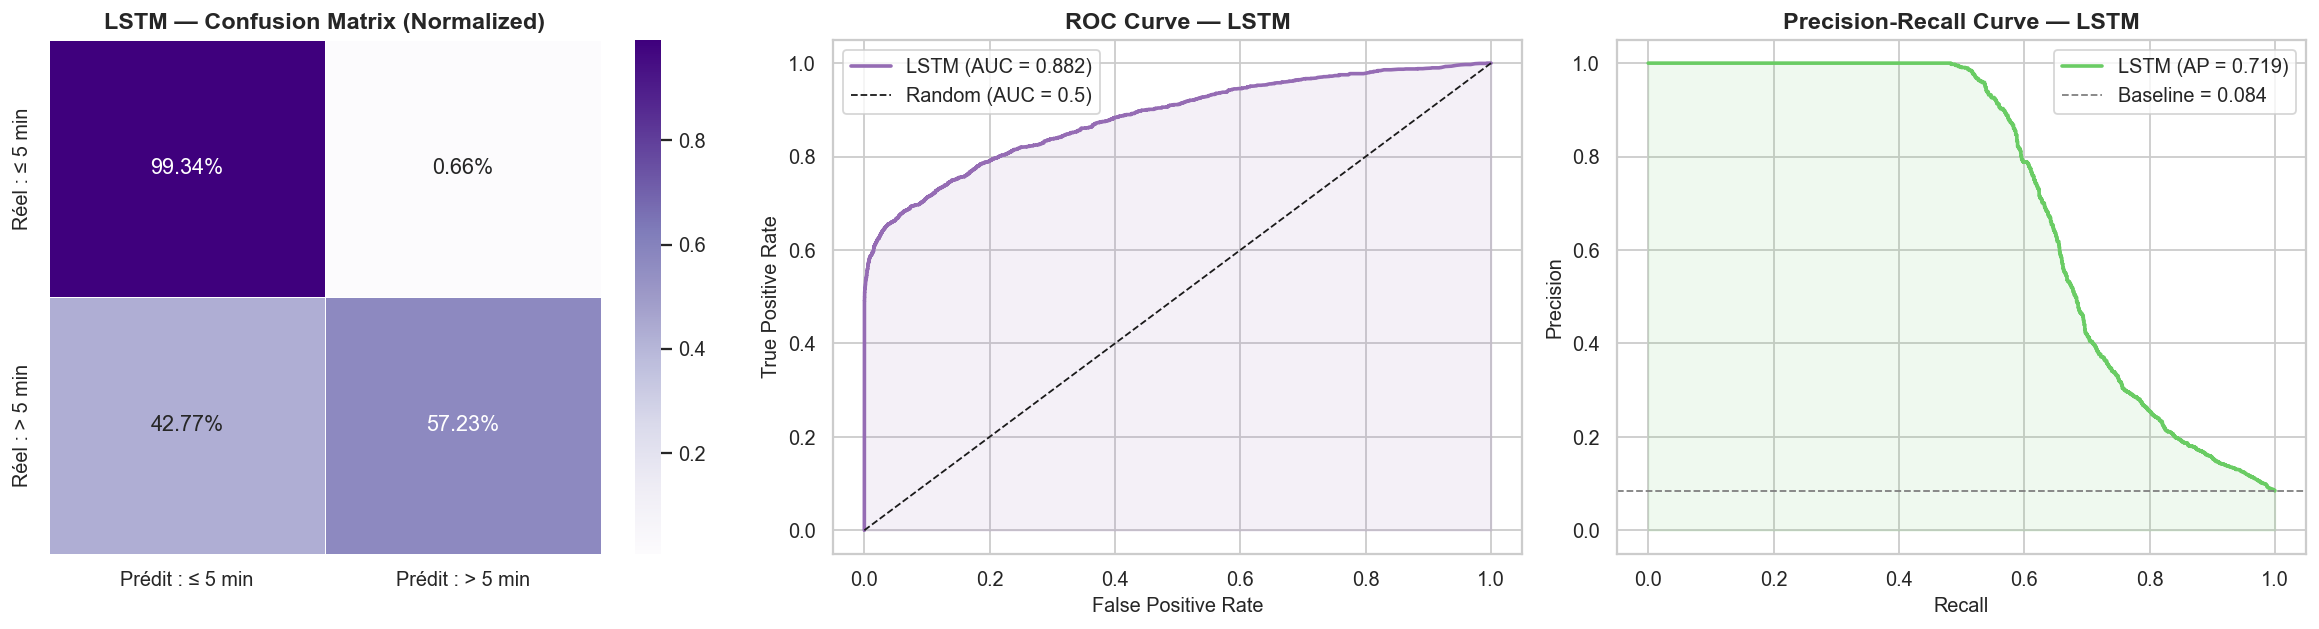

In [31]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Purples', ax=axes[0],
            xticklabels=['Prédit : ≤ 5 min', 'Prédit : > 5 min'],
            yticklabels=['Réel : ≤ 5 min', 'Réel : > 5 min'],
            linewidths=0.5, linecolor='white')
axes[0].set_title('LSTM — Confusion Matrix (Normalized)', fontweight='bold')

# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, lw=2, color=PALETTE[4], label=f'LSTM (AUC = {auc_roc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=PALETTE[4])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — LSTM', fontweight='bold')
axes[1].legend()

# ── Precision-Recall Curve ────────────────────────────────────────────────────
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
baseline = y_test.mean()
axes[2].plot(recall, precision, lw=2, color=PALETTE[2], label=f'LSTM (AP = {avg_prec:.3f})')
axes[2].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline = {baseline:.3f}')
axes[2].fill_between(recall, precision, alpha=0.1, color=PALETTE[2])
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve — LSTM', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('viz_lstm_evaluation.png', bbox_inches='tight')
plt.show()

### 12. Comparaison Finale — LR vs XGBoost vs LSTM

(En mettant laleurs LR et XGBoost obtenues dans les autres notebooks)

              Model   Cible  AUC-ROC  Avg Precision  F1 (retard)
Logistic Regression > 5 min 0.768000       0.264000     0.310000
            XGBoost > 5 min 0.816000       0.333000     0.311000
               LSTM > 5 min 0.882292       0.718809     0.696467


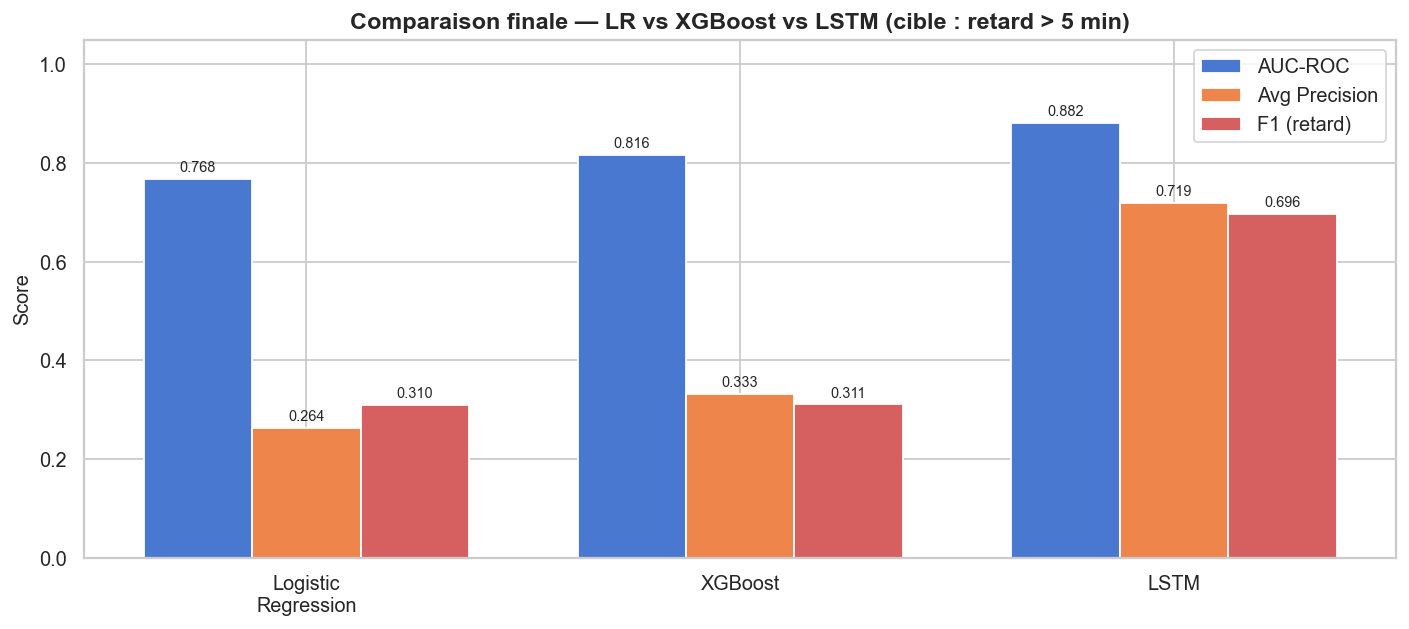

In [ ]:
# ── valeurs des notebooks précédents ─────────────────────────
LR_AUC   = 0.768
LR_AP    = 0.264
LR_F1    = 0.310

XGB_AUC  = 0.816   # XGBoost > 5 min
XGB_AP   = 0.333
XGB_F1   = 0.311

# LSTM 
LSTM_AUC = auc_roc
LSTM_AP  = avg_prec
LSTM_F1  = f1_sev

# ── Tableau récapitulatif ─────────────────────────────────────────────────────
results = pd.DataFrame({
    'Model'          : ['Logistic Regression', 'XGBoost', 'LSTM'],
    'Cible'          : ['> 5 min', '> 5 min', '> 5 min'],
    'AUC-ROC'        : [LR_AUC,  XGB_AUC,  LSTM_AUC],
    'Avg Precision'  : [LR_AP,   XGB_AP,   LSTM_AP],
    'F1 (retard)'    : [LR_F1,   XGB_F1,   LSTM_F1],
})
print(results.to_string(index=False))

# ── Visualisation ─────────────────────────────────────────────────────────────
models   = ['Logistic\nRegression', 'XGBoost', 'LSTM']
auc_vals = [LR_AUC, XGB_AUC, LSTM_AUC]
ap_vals  = [LR_AP,  XGB_AP,  LSTM_AP]
f1_vals  = [LR_F1,  XGB_F1,  LSTM_F1]

x     = np.arange(len(models))
width = 0.25
colors = [PALETTE[0], PALETTE[3], PALETTE[4]]

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width, auc_vals, width, label='AUC-ROC',       color=PALETTE[0])
b2 = ax.bar(x,         ap_vals,  width, label='Avg Precision',  color=PALETTE[1])
b3 = ax.bar(x + width, f1_vals,  width, label='F1 (retard)',    color=PALETTE[3])

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison finale — LR vs XGBoost vs LSTM (cible : retard > 5 min)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('viz_final_comparison.png', bbox_inches='tight')
plt.show()

### 13. Interprétation et Conclusion

#### Ce que le LSTM apporte

Contrairement à la LR et XGBoost qui voient chaque service comme **une ligne agrégée**, le LSTM exploite l'**ordre et la dynamique** des stops. Il peut par exemple apprendre que :
- Un retard croissant sur les 3 premiers stops prédit un retard final sévère
- Un changement de quai en milieu de trajet est un signal d'alerte

#### Limites de ce modèle

| Limite | Explication |
|---|---|
| Prédiction en temps réel uniquement | Les retards des stops intermédiaires ne sont pas connus avant le départ |
| Sous-échantillonnage | On a entraîné sur 100k services pour la rapidité — sur l'ensemble complet les performances seraient meilleures |
| Architecture simple | Un Transformer ou un LSTM bidirectionnel pourrait faire mieux |
